In [2]:
import pandas as pd

In [3]:
results = pd.read_parquet('../Results/results_xgb_byfips.parquet')

In [ ]:
# Add a column of residuals
results['residuals'] = results['y_true_max'] - results['y_pred_max']

In [7]:
results

,fips_code,split,datetime,y_pred_max,y_true_max,residuals
0,4001,0,2021-01-01 00:00,0.000012,0.000000e+00,-0.000012
1,4003,0,2021-01-01 00:00,0.000029,0.000000e+00,-0.000029
2,4005,0,2021-01-01 00:00,0.000124,9.299142e-06,-0.000115
3,4007,0,2021-01-01 00:00,0.000212,8.598118e-04,0.000648
4,4009,0,2021-01-01 00:00,0.000004,0.000000e+00,-0.000004
...,...,...,...,...,...,...
185780,45083,364,2021-12-31 00:00,0.000226,4.396656e-07,-0.000226
185781,45085,364,2021-12-31 00:00,0.000203,0.000000e+00,-0.000203
185782,45087,364,2021-12-31 00:00,0.000115,4.316149e-06,-0.000111
185783,45089,364,2021-12-31 00:00,0.000175,0.000000e+00,-0.000175


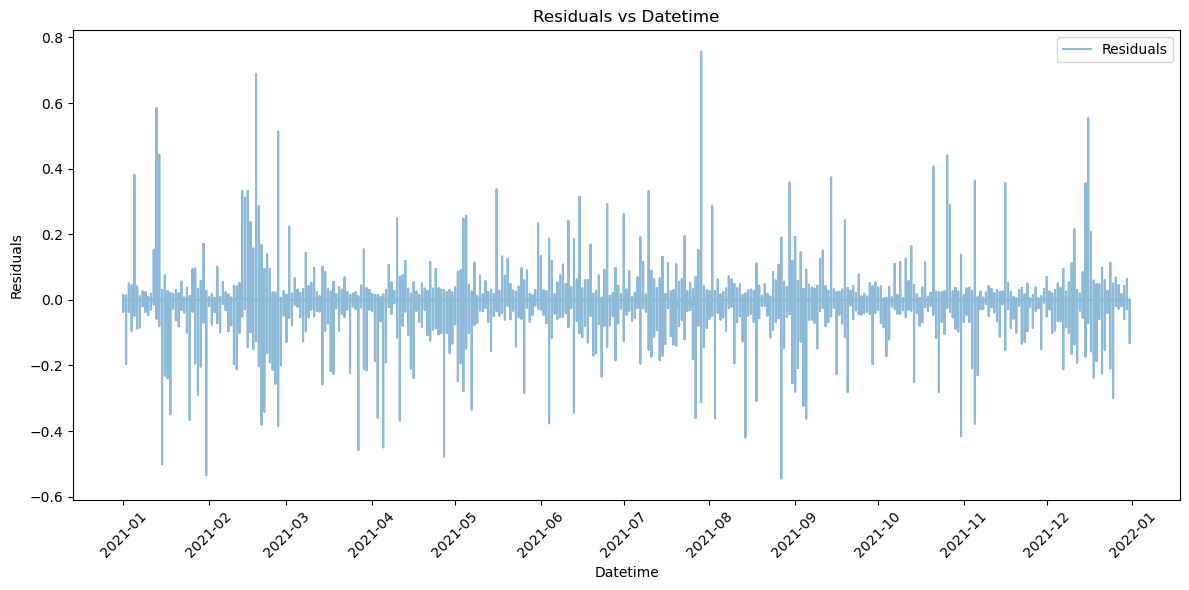

In [11]:
results['datetime'] = results['datetime'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(results['datetime'], results['residuals'], alpha=0.5, label='Residuals')
plt.xlabel('Datetime')
plt.ylabel('Residuals')
plt.title('Residuals vs Datetime')
plt.legend()

# Set x-axis ticks to every 1 month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

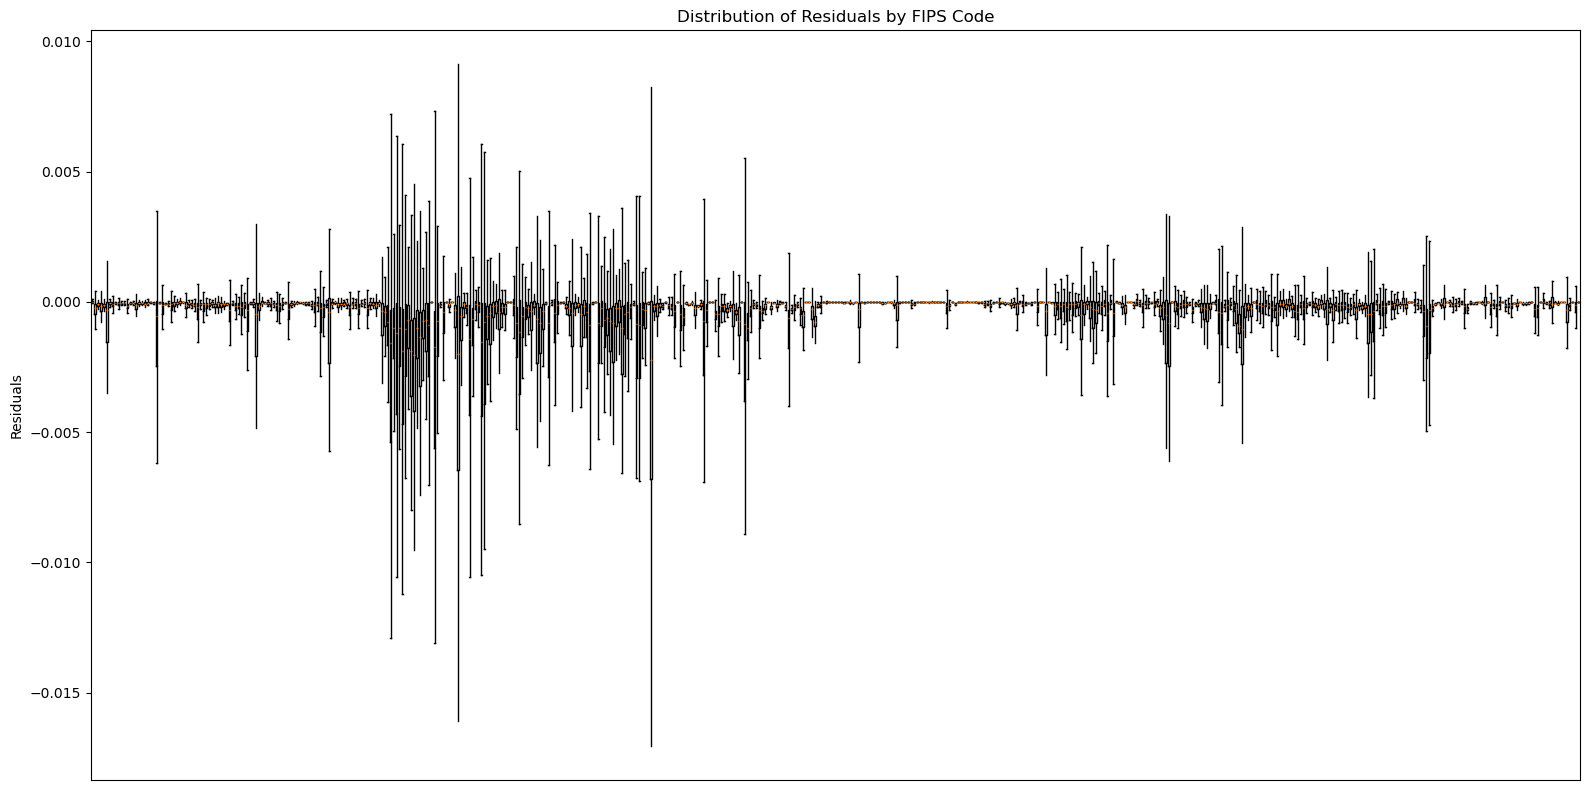

In [15]:
# Treat fips_code as ordered strings and plot the distribution of residuals
plt.figure(figsize=(16, 8))
plt.boxplot([results[results['fips_code'] == code]['residuals'] for code in results['fips_code'].unique()],
            showfliers=False)

plt.xlabel('')  # Remove x-axis label
plt.ylabel('Residuals')
plt.title('Distribution of Residuals by FIPS Code')
plt.xticks([])  # Remove x-axis tick labels
plt.tight_layout()
plt.show()